# Simple Quantum Circuits with Toy Datasets: Encoding Data
## 120 Training (Balanced) | Seed 42 | Target (y) = 3 Classes | Data Reupload = 2

## Setup

PennyLane is now imported as `qp` instead of `qml`.

Source: https://pennylane.ai/blog/2026/03/import-pennylane-as-qp-growing-beyond-just-qml

In [1]:
import torch

import pennylane as qp
from pennylane import numpy as np

import matplotlib.pyplot as plt

In [2]:
torch.__version__

'2.12.1+cu126'

In [3]:
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("No GPU available!")

NVIDIA GeForce GTX 1060


## Load Dataset: Iris

In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [5]:
iris = load_iris()
X = iris.data
y = iris.target

In [6]:
(X.shape, y.shape)

((150, 4), (150,))

In [7]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [8]:
# split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

((120, 4), (30, 4), (120,), (30,))

## Data Preprocessing

Features are standardized with `StandardScaler()` so each one maps to rotation angles on a comparable scale, rather than larger-magnitude features dominating the encoded state.

In [10]:
X_test

array([[4.4, 3. , 1.3, 0.2],
       [6.1, 3. , 4.9, 1.8],
       [4.9, 2.4, 3.3, 1. ],
       [5. , 2.3, 3.3, 1. ],
       [4.4, 3.2, 1.3, 0.2],
       [6.3, 3.3, 4.7, 1.6],
       [4.6, 3.6, 1. , 0.2],
       [5.4, 3.4, 1.7, 0.2],
       [6.5, 3. , 5.2, 2. ],
       [5.4, 3. , 4.5, 1.5],
       [7.3, 2.9, 6.3, 1.8],
       [6.9, 3.1, 5.1, 2.3],
       [6.5, 3. , 5.8, 2.2],
       [6.4, 3.2, 4.5, 1.5],
       [5. , 3.4, 1.5, 0.2],
       [5. , 3.3, 1.4, 0.2],
       [5.8, 4. , 1.2, 0.2],
       [5.6, 2.5, 3.9, 1.1],
       [6.1, 2.9, 4.7, 1.4],
       [6. , 3. , 4.8, 1.8],
       [5.4, 3.7, 1.5, 0.2],
       [6.7, 3.1, 5.6, 2.4],
       [6.6, 2.9, 4.6, 1.3],
       [6.1, 2.6, 5.6, 1.4],
       [6.4, 2.8, 5.6, 2.2],
       [6.7, 3. , 5. , 1.7],
       [6.6, 3. , 4.4, 1.4],
       [5.7, 3.8, 1.7, 0.3],
       [6.5, 3. , 5.5, 1.8],
       [5.2, 3.4, 1.4, 0.2]])

In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
# feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
X_test

array([[4.4, 3. , 1.3, 0.2],
       [6.1, 3. , 4.9, 1.8],
       [4.9, 2.4, 3.3, 1. ],
       [5. , 2.3, 3.3, 1. ],
       [4.4, 3.2, 1.3, 0.2],
       [6.3, 3.3, 4.7, 1.6],
       [4.6, 3.6, 1. , 0.2],
       [5.4, 3.4, 1.7, 0.2],
       [6.5, 3. , 5.2, 2. ],
       [5.4, 3. , 4.5, 1.5],
       [7.3, 2.9, 6.3, 1.8],
       [6.9, 3.1, 5.1, 2.3],
       [6.5, 3. , 5.8, 2.2],
       [6.4, 3.2, 4.5, 1.5],
       [5. , 3.4, 1.5, 0.2],
       [5. , 3.3, 1.4, 0.2],
       [5.8, 4. , 1.2, 0.2],
       [5.6, 2.5, 3.9, 1.1],
       [6.1, 2.9, 4.7, 1.4],
       [6. , 3. , 4.8, 1.8],
       [5.4, 3.7, 1.5, 0.2],
       [6.7, 3.1, 5.6, 2.4],
       [6.6, 2.9, 4.6, 1.3],
       [6.1, 2.6, 5.6, 1.4],
       [6.4, 2.8, 5.6, 2.2],
       [6.7, 3. , 5. , 1.7],
       [6.6, 3. , 4.4, 1.4],
       [5.7, 3.8, 1.7, 0.3],
       [6.5, 3. , 5.5, 1.8],
       [5.2, 3.4, 1.4, 0.2]])

## Angle Encoding without Data Reuploading

- In this notebook, the 4 features of the Iris dataset are encoded into 4 qubits (one feature per qubit).
- Since each qubit has 2 basis states, the 4 qubits span 16 computational basis states ($2^4 = 16$).
    - **Note**: Not 16 independent states per qubit.
- `qp.state()` returns the quantum statevector (complex amplitudes in the computational basis). There are 16 elements in this vector.
    - Source: https://docs.pennylane.ai/en/stable/code/api/pennylane.state.html
- `qp.probs()` returns the probability vector for measuring each computational basis state. There are 16 elements in this vector.
    - Source: https://docs.pennylane.ai/en/stable/code/api/pennylane.probs.html
- Each probability equals the squared magnitude of the corresponding amplitude: $p[i] = |psi[i]|^2$.

Source: https://docs.pennylane.ai/en/stable/code/api/pennylane.AngleEmbedding.html

In [14]:
# initialize device
dev = qp.device("default.qubit", wires=4) # 4 features = 4 qubits

In [15]:
# define circuit to encode data
@qp.qnode(dev)
def encoder_circuit(feature_vector):
    qp.AngleEmbedding(features=feature_vector, wires=range(4), rotation='Y')
    return qp.state(), qp.probs(wires=range(4)) # get state and probabilities

### Quantum State and Probabilities

`np.allclose()` can be used to check if two arrays are equal (element-wise).

Source: https://numpy.org/doc/stable/reference/generated/numpy.allclose.html

Scaled data: [-1.72156775 -0.33210111 -1.34572231 -1.32327558]

Quantum state vector:
[ 0.3967+0.j -0.3089+0.j -0.3161+0.j  0.2462+0.j -0.0665+0.j  0.0518+0.j
  0.053 +0.j -0.0413+0.j -0.4615+0.j  0.3594+0.j  0.3678+0.j -0.2864+0.j
  0.0773+0.j -0.0602+0.j -0.0616+0.j  0.048 +0.j]

Probabilities vector:
[0.1573 0.0954 0.0999 0.0606 0.0044 0.0027 0.0028 0.0017 0.213  0.1291
 0.1353 0.082  0.006  0.0036 0.0038 0.0023]

Verify probs == |psi|^2: True


Text(0, 0.5, 'probability')

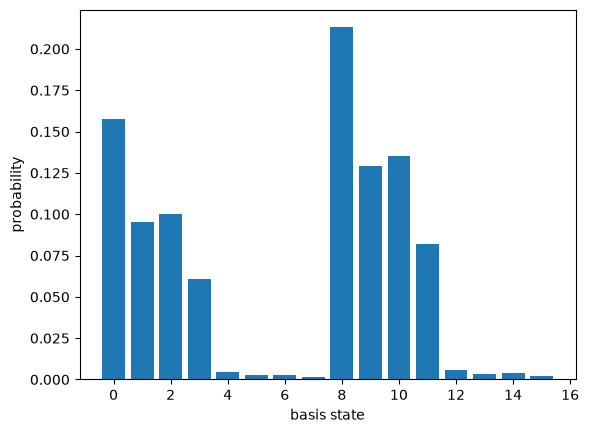

In [16]:
# sample one feature vector
x = X_train_scaled[0]

# encode data
psi, p = encoder_circuit(x)

print(f"Scaled data: {x}")
print(f"\nQuantum state vector:\n{np.round(psi, 4)}")
print(f"\nProbabilities vector:\n{np.round(p, 4)}")
print(f"\nVerify probs == |psi|^2: {np.allclose(p, np.abs(psi)**2)}")

plt.bar(range(16), p) # 4 qubits * 2 basis states = 16 states
plt.xlabel("basis state")
plt.ylabel("probability")

Scaled data: [-1.24390734 -0.10821272 -1.34572231 -1.19160637]

Quantum state vector:
[ 0.5253+0.j -0.3562+0.j -0.4186+0.j  0.2838+0.j -0.0285+0.j  0.0193+0.j
  0.0227+0.j -0.0154+0.j -0.3766+0.j  0.2553+0.j  0.3001+0.j -0.2035+0.j
  0.0204+0.j -0.0138+0.j -0.0163+0.j  0.011 +0.j]

Probabilities vector:
[2.760e-01 1.268e-01 1.753e-01 8.060e-02 8.000e-04 4.000e-04 5.000e-04
 2.000e-04 1.418e-01 6.520e-02 9.010e-02 4.140e-02 4.000e-04 2.000e-04
 3.000e-04 1.000e-04]

Verify probs == |psi|^2: True


Text(0, 0.5, 'probability')

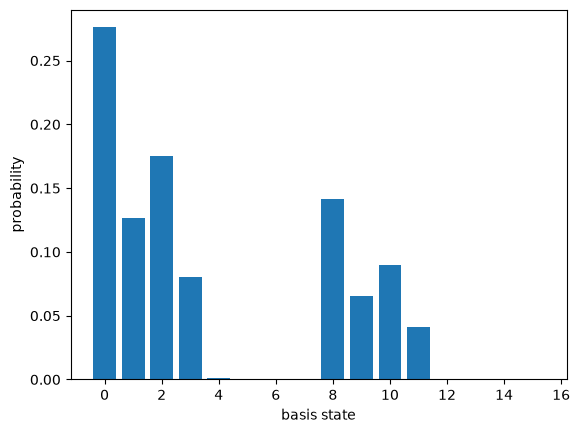

In [17]:
# sample one feature vector
x = X_train_scaled[50]

# encode data
psi, p = encoder_circuit(x)

print(f"Scaled data: {x}")
print(f"\nQuantum state vector:\n{np.round(psi, 4)}")
print(f"\nProbabilities vector:\n{np.round(p, 4)}")
print(f"\nVerify probs == |psi|^2: {np.allclose(p, np.abs(psi)**2)}")

plt.bar(range(16), p) # 4 qubits * 2 basis states = 16 basic states
plt.xlabel("basis state")
plt.ylabel("probability")

### Sampling

Source: https://docs.pennylane.ai/en/stable/code/api/pennylane.sample.html

In [18]:
# define circuit to encode data
@qp.set_shots(shots=1000)
@qp.qnode(dev)
def encoder_circuit_sampling(feature_vector):
    qp.AngleEmbedding(features=feature_vector, wires=range(4), rotation='Y')
    return qp.sample(wires=range(4)) # get sampling results

In [19]:
# sample one feature vector
x = X_train_scaled[0]

# encode data
results = encoder_circuit_sampling(x)

print(f"Results shape: {results.shape}")
print(f"Results: {results}")

Results shape: (1000, 4)
Results: [[0 0 1 0]
 [0 0 1 0]
 [1 0 0 0]
 ...
 [1 0 0 1]
 [1 0 0 1]
 [1 0 0 0]]


In PennyLane, wire0 is the leftmost bit. This gives [wire0 wire1 wire2 wire3].

Source: https://discuss.pennylane.ai/t/correct-wire-ordering-for-operations-on-3-wires/392

In [20]:
def row_to_basis(row):
    """To convert samping result string to binary form"""
    return "".join(str(int(b)) for b in row)

def row_to_index(row):
    """To covert binary to decimal equivalent"""
    return int(row_to_basis(row), 2)

In [21]:
from collections import Counter

In [22]:
counts = Counter(row_to_index(r) for r in results)

print(f"Most common sampling results:")
for idx, n in counts.most_common():
    print(f" |{idx:04b}⟩ (decimal {idx}): {n}")

Most common sampling results:
 |1000⟩ (decimal 8): 179
 |0000⟩ (decimal 0): 163
 |1010⟩ (decimal 10): 133
 |0010⟩ (decimal 2): 120
 |1001⟩ (decimal 9): 117
 |0001⟩ (decimal 1): 116
 |0011⟩ (decimal 3): 72
 |1011⟩ (decimal 11): 72
 |0110⟩ (decimal 6): 8
 |1110⟩ (decimal 14): 6
 |0100⟩ (decimal 4): 4
 |1100⟩ (decimal 12): 4
 |1101⟩ (decimal 13): 3
 |1111⟩ (decimal 15): 2
 |0111⟩ (decimal 7): 1


## Angle Encoding with Data Reuploading

Using the illustrations in the PennyLane tutorial for the purpose of learning, we have:

<img src="img/universal_dnn.png" width="30%">

- Top diagram, quantum side:
    - 1 wire = 1 qubit.
    - 2 squares = 2 gates.
    - 3 blocks (A, B, C) = data re-uploaded 3 times on 1 qubit.
    - 2 gates per block x 3 blocks = 6 gates on 1 qubit.
- Bottom diagram, quantum side:
    - 2 wires = 2 qubits.
    - 2 squares = 2 gates.
    - 2 blocks (A, B) = data reuploaded 2 times on each qubit.
    - 2 gates per block x 2 blocks = 4 gates on each qubit.
    - Entanglement between 2 blocks.

Source: https://pennylane.ai/demos/tutorial_data_reuploading_classifier

In [23]:
# initialize device
num_qubits = 4 # 4 features = 4 qubits
dev1 = qp.device("default.qubit", wires=num_qubits)

# reupload same classical data 2 times
num_layers = 2

`qp.StronglyEntanglingLayers()` can create entanglements between all available qubits.

Source: https://docs.pennylane.ai/en/stable/code/api/pennylane.StronglyEntanglingLayers.html

In [24]:
shape = qp.StronglyEntanglingLayers.shape(n_layers=num_layers, n_wires=num_qubits)
rng = np.random.default_rng(12345)

print(f"weight shape: {shape}")

weight shape: (2, 4, 3)


In [25]:
# initialize trainable weights
weights = np.array(rng.random(size=shape), requires_grad=True)
weights

tensor([[[0.22733602, 0.31675834, 0.79736546],
         [0.67625467, 0.39110955, 0.33281393],
         [0.59830875, 0.18673419, 0.67275604],
         [0.94180287, 0.24824571, 0.94888115]],

        [[0.66723745, 0.09589794, 0.44183967],
         [0.88647992, 0.6974535 , 0.32647286],
         [0.73392816, 0.22013496, 0.08159457],
         [0.1598956 , 0.34010018, 0.46519315]]], requires_grad=True)

In [26]:
@qp.qnode(dev1)
def encoder_circuit_with_reupload(x, weights):
    for l in range(num_layers):                                                  # reupload num_layers times
        qp.AngleEmbedding(x, wires=range(num_qubits), rotation="Y")              # 1. encode data with data reuploading
        qp.StronglyEntanglingLayers(weights[l : l + 1], wires=range(num_qubits)) # 2. trainable quantum layer + entanglement

    return [qp.expval(qp.PauliZ(j)) for j in range(num_qubits)]                  # 3. readout for Iris 3-class classification

In [27]:
# sample one feature vector
x = X_train_scaled[0]

# single inference forward pass with fixed random weights (no training)
outputs = encoder_circuit_with_reupload(x, weights)
outputs

[tensor(-0.5052729, requires_grad=True),
 tensor(-0.02242274, requires_grad=True),
 tensor(0.02632413, requires_grad=True),
 tensor(-0.0322564, requires_grad=True)]

## References

- Importing PennyLane as qp: https://pennylane.ai/blog/2026/03/import-pennylane-as-qp-growing-beyond-just-qml
- Encoding data in angles: https://docs.pennylane.ai/en/stable/code/api/pennylane.AngleEmbedding.html
- Wire 0 always corresponds to the leftmost index: https://discuss.pennylane.ai/t/correct-wire-ordering-for-operations-on-3-wires/392
- Quantum state in the computational basis: https://docs.pennylane.ai/en/stable/code/api/pennylane.state.html
- Finding probability of each computational basis state: https://docs.pennylane.ai/en/stable/code/api/pennylane.probs.html
- Checking if two arrays are equal (element-wise): https://numpy.org/doc/stable/reference/generated/numpy.allclose.html
- Sampling/measuring the quantum state: https://docs.pennylane.ai/en/stable/code/api/pennylane.sample.html
- Data reuploading: https://pennylane.ai/demos/tutorial_data_reuploading_classifier
- Strong entangling layers: https://docs.pennylane.ai/en/stable/code/api/pennylane.StronglyEntanglingLayers.html